<h1><b>Health Insurance Cross Sell Prediction</b></h1>

<h3><b>Objective</b></h3>
The task is a regression problem, where we aim to predict the target variable Pawpularity for pet images based on a variety of features.

This notebook presents an end-to-end machine learning solution using a binary classification model to predict whether a customer will opt for vehicle insurance (Response = 1) or not (Response = 0).

The dataset contains information about customer demographics and vehicle details, with the following features:

* Gender, Age, Driving_License, Region_Code, Previously_Insured

* Vehicle_Age, Vehicle_Damage, Annual_Premium

* Policy_Sales_Channel, Vintage

* Target variable: Response

Our objective is to:

* Perform exploratory data analysis (EDA) to understand data distributions and relationships.  

* Apply data preprocessing and feature engineering.

* Train and evaluate various regression models (such as Linear Regression, Random Forest, and XGBoost).

* Optimize model performance using cross-validation and hyperparameter tuning.

* Interpret model results and analyze feature importance.

<h2><b>IMPORTING ALL LIBRARIES</b><h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import seaborn as sns
import warnings

<h2><b>Loading CSV</b></h1>

In [2]:
df = pd.read_csv("train.csv")
df.head(20)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
5,6,Female,24,1,33.0,0,< 1 Year,Yes,2630.0,160.0,176,0
6,7,Male,23,1,11.0,0,< 1 Year,Yes,23367.0,152.0,249,0
7,8,Female,56,1,28.0,0,1-2 Year,Yes,32031.0,26.0,72,1
8,9,Female,24,1,3.0,1,< 1 Year,No,27619.0,152.0,28,0
9,10,Female,32,1,6.0,1,< 1 Year,No,28771.0,152.0,80,0


In [3]:
# Convert Gender column: Male = 1, Female = 0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [4]:
# Vehicle Age encoding
df['Vehicle_Age'] = df['Vehicle_Age'].map({
    '< 1 Year': 0,
    '1-2 Year': 1,
    '> 2 Years': 2
})

In [5]:
# Vehicle Damage encoding
df['Vehicle_Damage'] = df['Vehicle_Damage'].map({
    'No': 0,
    'Yes': 1
})

In [7]:
df.to_csv("processed_train_data.csv", index=False)

In [8]:
df = pd.read_csv("processed_train_data.csv")
df.head(20)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,1,44,1,28.0,0,2,1,40454.0,26.0,217,1
1,2,1,76,1,3.0,0,1,0,33536.0,26.0,183,0
2,3,1,47,1,28.0,0,2,1,38294.0,26.0,27,1
3,4,1,21,1,11.0,1,0,0,28619.0,152.0,203,0
4,5,0,29,1,41.0,1,0,0,27496.0,152.0,39,0
5,6,0,24,1,33.0,0,0,1,2630.0,160.0,176,0
6,7,1,23,1,11.0,0,0,1,23367.0,152.0,249,0
7,8,0,56,1,28.0,0,1,1,32031.0,26.0,72,1
8,9,0,24,1,3.0,1,0,0,27619.0,152.0,28,0
9,10,0,32,1,6.0,1,0,0,28771.0,152.0,80,0


In [9]:
df.shape

(381109, 12)

In [10]:
df.describe()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,0.540761,38.822584,0.997869,26.388807,0.458210,0.609616,0.504877,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,0.498336,15.511611,0.046110,13.229888,0.498251,0.567439,0.499977,17213.155057,54.203995,83.671304,0.327936
min,1.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,0.000000,25.000000,1.000000,15.000000,0.000000,0.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,1.000000,36.000000,1.000000,28.000000,0.000000,1.000000,1.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,1.000000,49.000000,1.000000,35.000000,1.000000,1.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,1.000000,85.000000,1.000000,52.000000,1.000000,2.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


The below traget distribution graphs depicts the target distribution present in the original dataset.

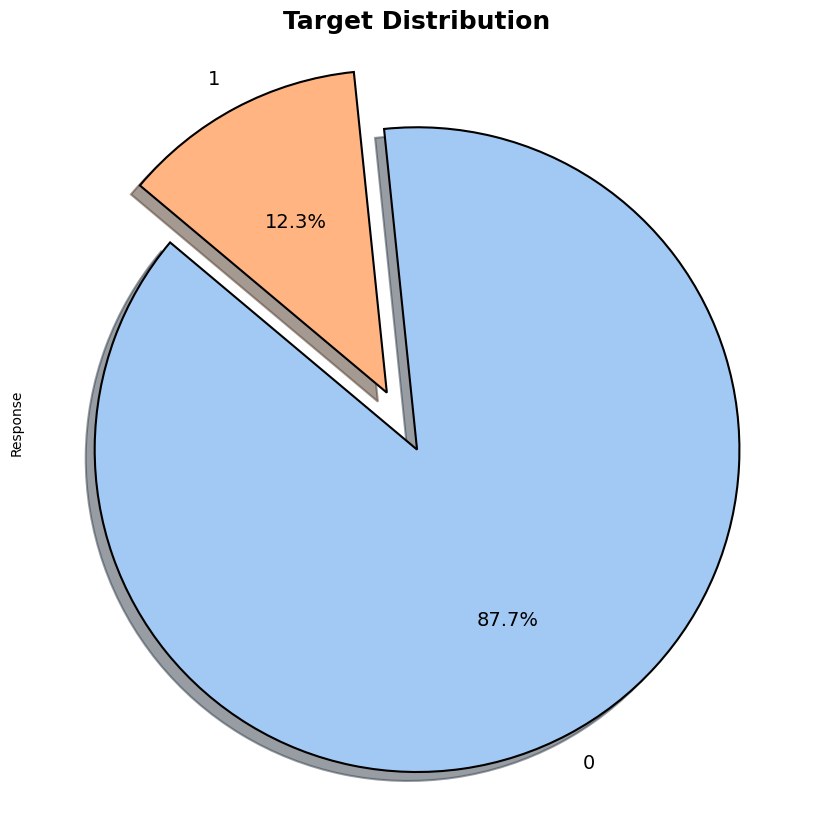

In [11]:
plt.figure(figsize=(10, 10))
palette_color = sns.color_palette('pastel')
explode = [0.1 for _ in range(df['Response'].nunique())]
df.groupby('Response')['Response'].count().plot.pie(
    colors=palette_color,
    explode=explode,
    autopct="%1.1f%%",
    shadow=True,
    startangle=140,
    textprops={'fontsize': 14},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)

plt.title('Target Distribution', fontsize=18, weight='bold')
plt.axis('equal')
plt.show()

In [12]:
df.nunique().sort_values()

,0
Gender,2
Driving_License,2
Vehicle_Damage,2
Previously_Insured,2
Response,2
Vehicle_Age,3
Region_Code,53
Age,66
Policy_Sales_Channel,155
Vintage,290


In [13]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Vehicle_Damage,0
Annual_Premium,0
Policy_Sales_Channel,0


In [14]:
print(df['Gender'].unique())
print(df['Vehicle_Age'].unique())
print(df['Vehicle_Damage'].unique())


[1 0]
[2 1 0]
[1 0]


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  int64  
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  int64  
 7   Vehicle_Damage        381109 non-null  int64  
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 34.9 MB


To simplify preprocessing, I divided the input features into three types:

* Binary Features: Columns with only two possible values (e.g., 0 or 1).

* Categorical Features: Columns with discrete categories (e.g., 'Male', 'Female').

* Continuous Features: All remaining numeric features.

In [16]:
'''feature_list = [feature for feature in df.columns if not feature  == "Response"]
target = "Response"
binary_features = ['Previously_Insured','Driving_License']
categorical_features = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']
df[categorical_features] = df[categorical_features].astype('category')

continuous_features = list(set(feature_list) - set(binary_features)- set(categorical_features))
assert feature_list.sort() == (continuous_features + binary_features + categorical_features).sort()'''

'feature_list = [feature for feature in df.columns if not feature  == "Response"]\ntarget = "Response"\nbinary_features = [\'Previously_Insured\',\'Driving_License\']\ncategorical_features = [\'Gender\', \'Vehicle_Age\', \'Vehicle_Damage\']\ndf[categorical_features] = df[categorical_features].astype(\'category\')\n\ncontinuous_features = list(set(feature_list) - set(binary_features)- set(categorical_features))\nassert feature_list.sort() == (continuous_features + binary_features + categorical_features).sort()'

Encoding the categorical and binary columns into numericals columns by mapping them.

In [17]:
'''import pandas as pd

cat_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Vehicle_Damage'] = df['Vehicle_Damage'].map({'No': 0, 'Yes': 1})
df['Vehicle_Age'] = df['Vehicle_Age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2})

print(df.head())
'''

"import pandas as pd\n\ncat_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage']\ndf['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})\ndf['Vehicle_Damage'] = df['Vehicle_Damage'].map({'No': 0, 'Yes': 1})\ndf['Vehicle_Age'] = df['Vehicle_Age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2})\n\nprint(df.head())\n"

<h2><b>Exploratory Data Analysis</b></h2>

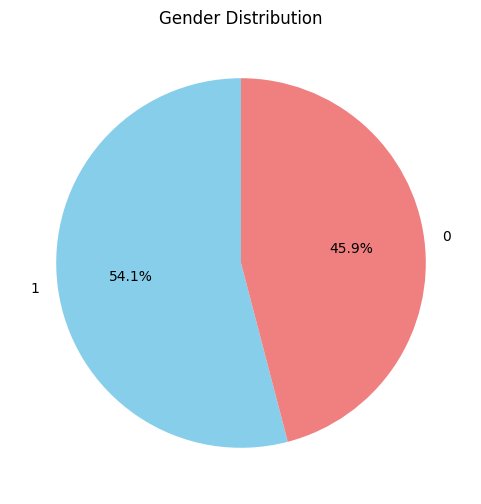

In [18]:
%matplotlib inline
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index, autopct='%1.1f%%',
    colors=['skyblue', 'lightcoral'],
    startangle=90
)
plt.title('Gender Distribution')
plt.show()


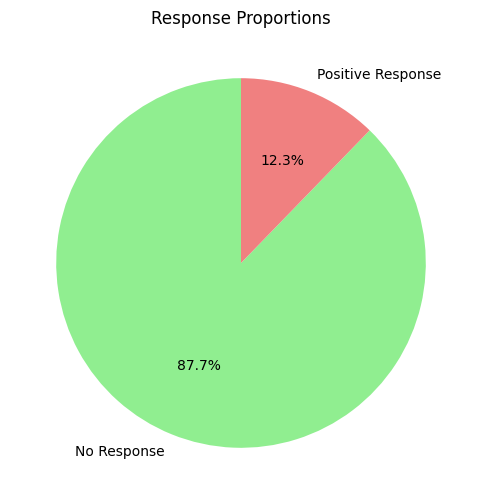

In [19]:
response_counts = df['Response'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(response_counts, labels=['No Response', 'Positive Response'], autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
plt.title('Response Proportions')
plt.show()

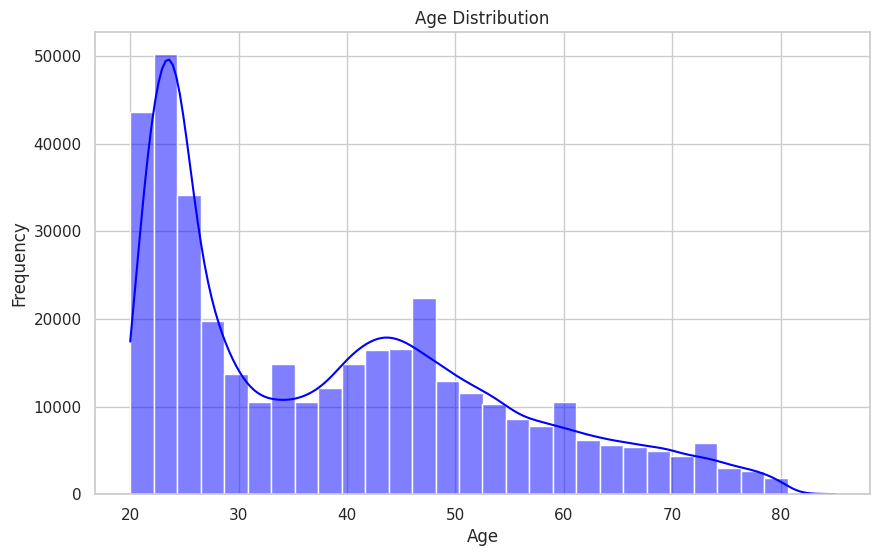

In [20]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_2999/4190735372.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Driving_License', data=df, palette='Set2')


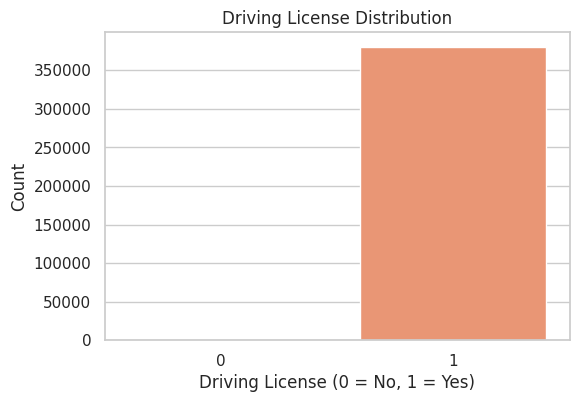

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Driving_License', data=df, palette='Set2')
plt.title('Driving License Distribution')
plt.xlabel('Driving License (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_2999/1352717576.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Previously_Insured', data=df, palette='Set1')


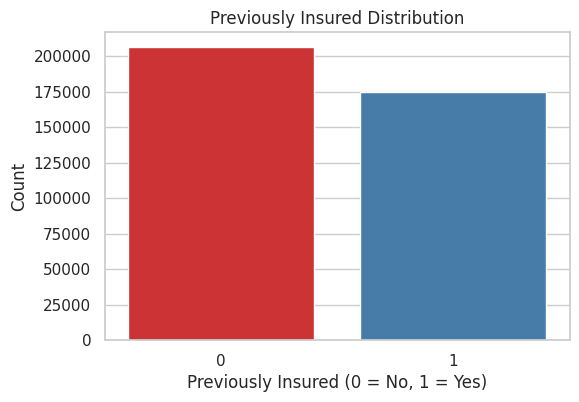

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Previously_Insured', data=df, palette='Set1')
plt.title('Previously Insured Distribution')
plt.xlabel('Previously Insured (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_2999/835567985.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age', y='Response', data=age_response, palette='coolwarm')


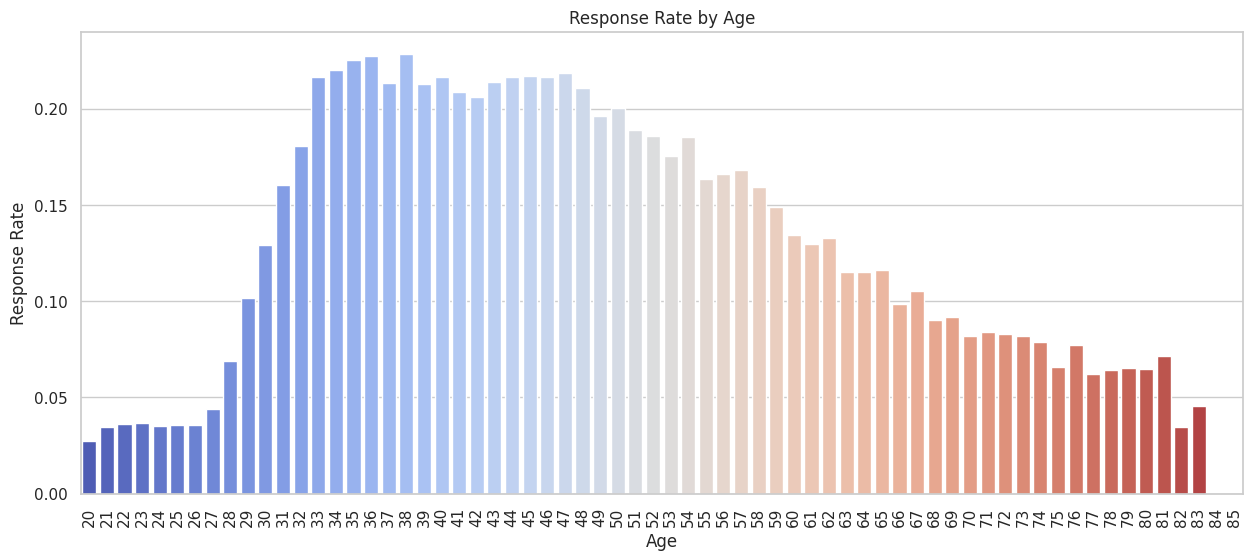

In [23]:
plt.figure(figsize=(15, 6))
age_response = df.groupby('Age')['Response'].mean().reset_index()
sns.barplot(x='Age', y='Response', data=age_response, palette='coolwarm')
plt.title('Response Rate by Age')
plt.xlabel('Age')
plt.ylabel('Response Rate')
plt.xticks(rotation=90)
plt.show()

/tmp/ipykernel_2999/2859471213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Previously_Insured', y='Response', data=insured_response, palette='viridis')


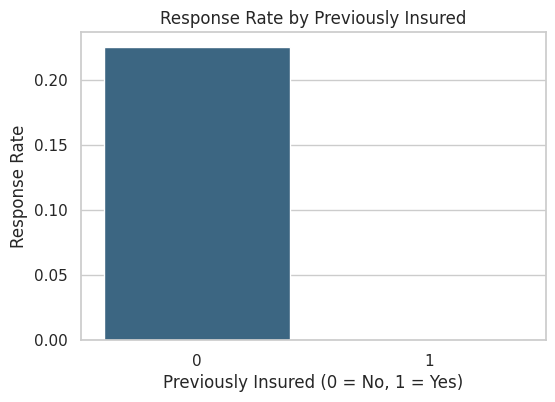

In [24]:
plt.figure(figsize=(6, 4))
insured_response = df.groupby('Previously_Insured')['Response'].mean().reset_index()
sns.barplot(x='Previously_Insured', y='Response', data=insured_response, palette='viridis')
plt.title('Response Rate by Previously Insured')
plt.xlabel('Previously Insured (0 = No, 1 = Yes)')
plt.ylabel('Response Rate')
plt.show()

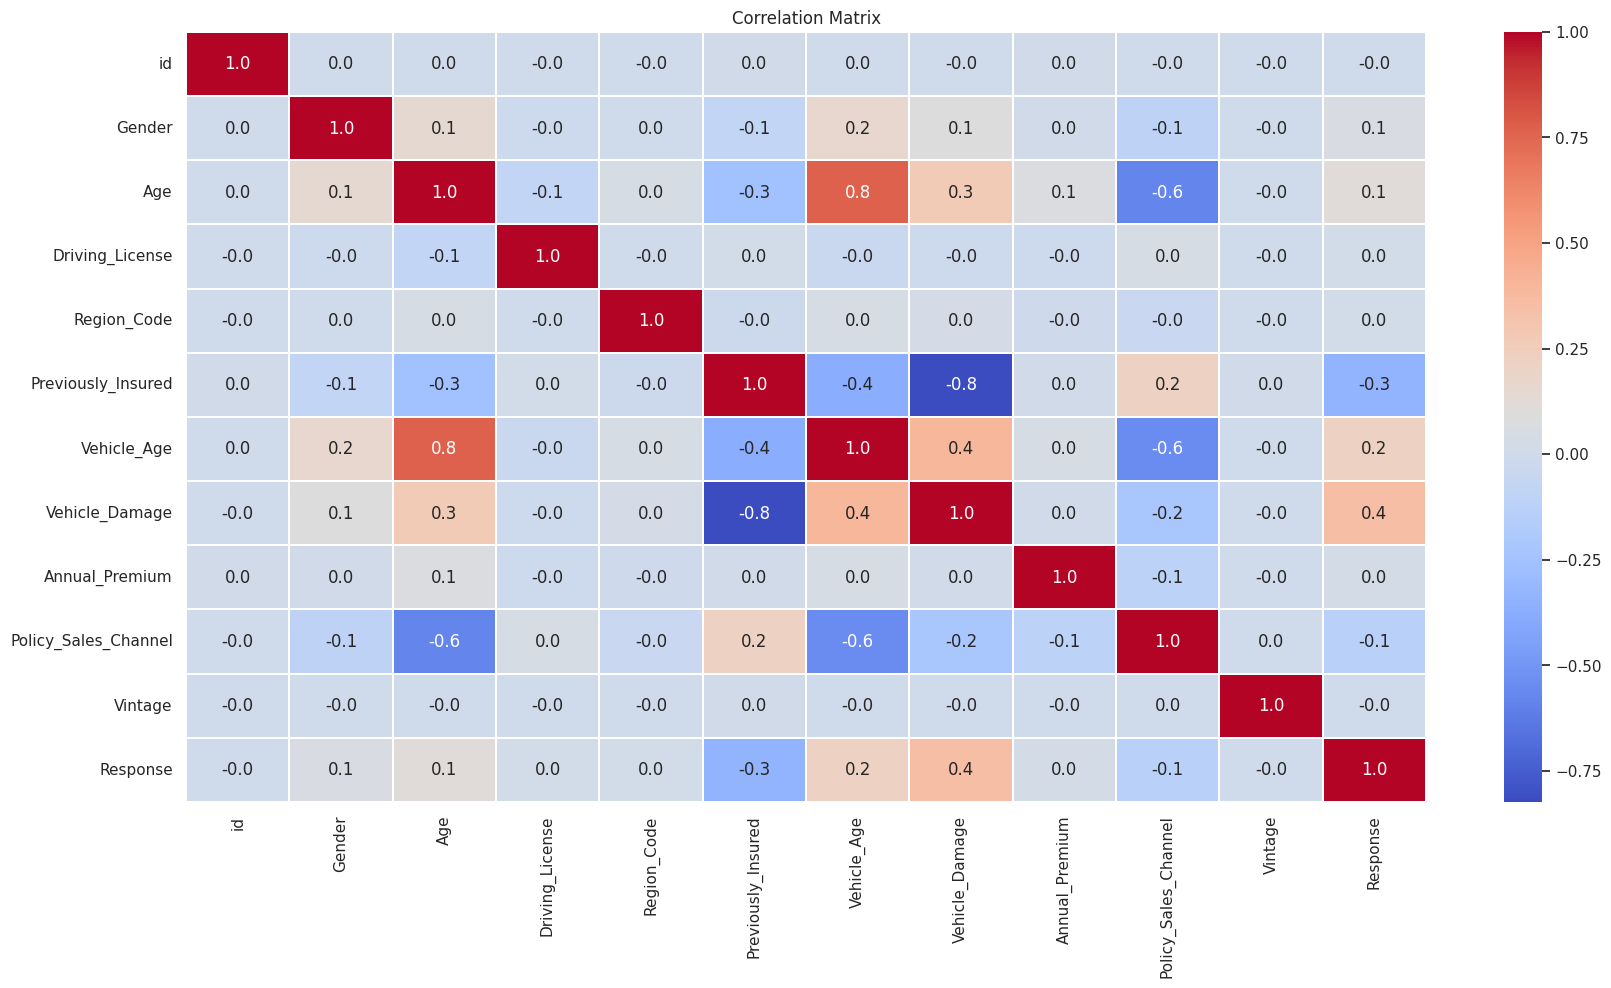

In [25]:
correlation_matrix = df.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.1)

plt.title('Correlation Matrix')
plt.show()

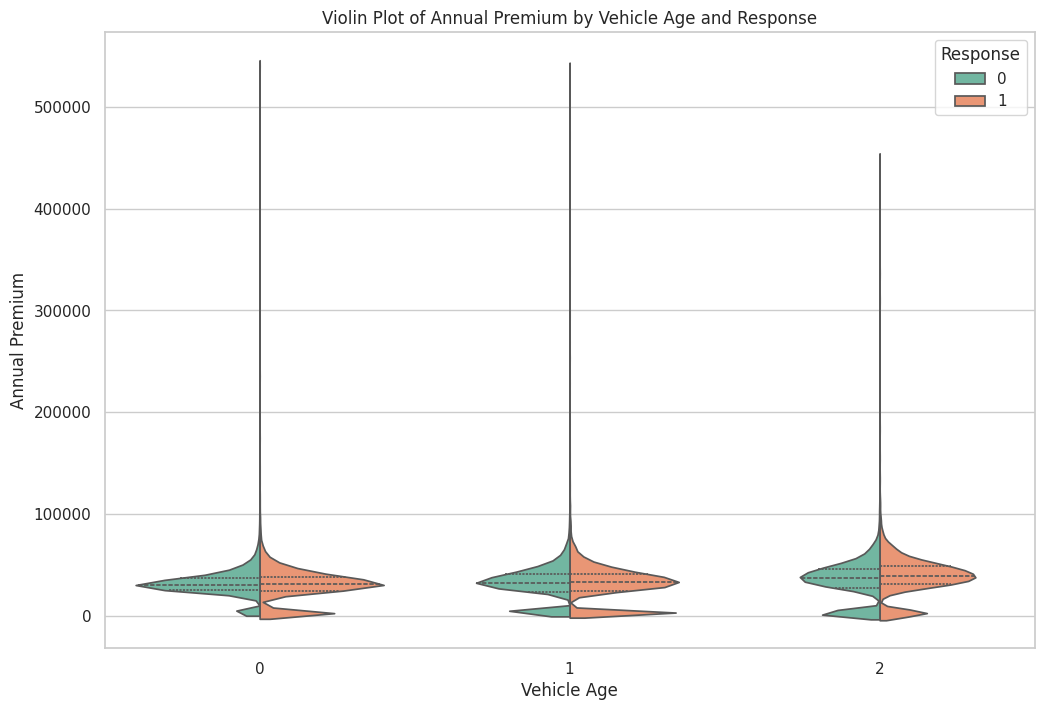

In [26]:
plt.figure(figsize=(12, 8))
sns.violinplot(x='Vehicle_Age', y='Annual_Premium', data=df, hue='Response', split=True, palette='Set2', inner='quartile')
plt.title('Violin Plot of Annual Premium by Vehicle Age and Response')
plt.xlabel('Vehicle Age')
plt.ylabel('Annual Premium')
plt.show()

<h2><b>Model Training</b><h1>



* The first step is to seperate the dependent and independent variable so that we can split the dataset into
 training and test data

In [27]:
y = df['Response']
X = df.drop(['Response'],axis=1)

* The train_test_split methods help in splitting the dataset into two part : Training and Testing

* size of train data = 80% and test data= 20%

* Using this method the values of randomly selected data once doesnot change always when we rerun the code.

In [28]:
train_X, test_X, train_y, test_y = train_test_split(X, y,test_size = 0.2, random_state =42)

In [29]:
train_X = train_X.to_numpy()
train_y = train_y.to_numpy()
test_X = test_X.to_numpy()
test_y = test_y.to_numpy()

<h1>Decision Tree</h1>

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report

X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
predictions = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.8400

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        89
           1       0.87      0.84      0.85       111

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



<b>The accuracy of the the Decision tree model is 84.00%</b>

<h1>LOGISTIC REGRESSION</h1>

In [40]:
from sklearn.linear_model import LogisticRegression
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

predictions = log_reg_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.8300

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82        89
           1       0.87      0.82      0.84       111

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



<b> The Accuracy of Logistic Regression model is 83.00% </b>

<h1>RANDOM FOREST CLASSIFIER</h1>

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report

X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.8800

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        89
           1       0.91      0.86      0.89       111

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



<b>The accuracy of the Random forest classifier model is 88 % </b>

<h1>XGBOOSTING CLASSIFIER</h1>

In [42]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import gc
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'eta': 0.03,
    'alpha': 0.1,
    'subsample': 0.851,
    'colsample_bytree': 0.45,
    'max_depth': 12,
    'min_child_weight': 10,
    'gamma': 1e-6,
    'random_state': 42,
    'max_bin': 100,
    'enable_categorical': True,
    'n_estimators': 100,
    'tree_method': 'hist',
    'early_stopping_rounds':50,
    'verbose':50
}
gc.collect()
xgb_model = XGBClassifier(**params,device="cuda")
XGB = xgb_model.fit(
    train_X,
    train_y,
    eval_set=[(test_X, test_y)]
)

[0]	validation_0-auc:0.84423


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [17:03:54] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [17:03:54] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [17:03:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  self.starting_round = model.num_boosted_rounds()


[1]	validation_0-auc:0.84173
[2]	validation_0-auc:0.84765
[3]	validation_0-auc:0.84655
[4]	validation_0-auc:0.84768
[5]	validation_0-auc:0.84407
[6]	validation_0-auc:0.84266
[7]	validation_0-auc:0.84116
[8]	validation_0-auc:0.84506
[9]	validation_0-auc:0.84556
[10]	validation_0-auc:0.84746
[11]	validation_0-auc:0.84843
[12]	validation_0-auc:0.84909
[13]	validation_0-auc:0.85051
[14]	validation_0-auc:0.85286
[15]	validation_0-auc:0.85358
[16]	validation_0-auc:0.85352
[17]	validation_0-auc:0.85410
[18]	validation_0-auc:0.85451
[19]	validation_0-auc:0.85498
[20]	validation_0-auc:0.85548
[21]	validation_0-auc:0.85560
[22]	validation_0-auc:0.85583
[23]	validation_0-auc:0.85575
[24]	validation_0-auc:0.85587
[25]	validation_0-auc:0.85551
[26]	validation_0-auc:0.85608
[27]	validation_0-auc:0.85644
[28]	validation_0-auc:0.85642
[29]	validation_0-auc:0.85651
[30]	validation_0-auc:0.85696
[31]	validation_0-auc:0.85724
[32]	validation_0-auc:0.85734
[33]	validation_0-auc:0.85727
[34]	validation_0-a

In [34]:
prediction = XGB.predict(test_X)

In [35]:
val_pred_prob = XGB.predict_proba(test_X)[:, 1]
auc = roc_auc_score(test_y, val_pred_prob)
print(f"Validation AUC: {auc:.5f}")

Validation AUC: 0.85818


<b>The Area Under The Curve of the XGBoosting Classifier is 86.98 % </b>

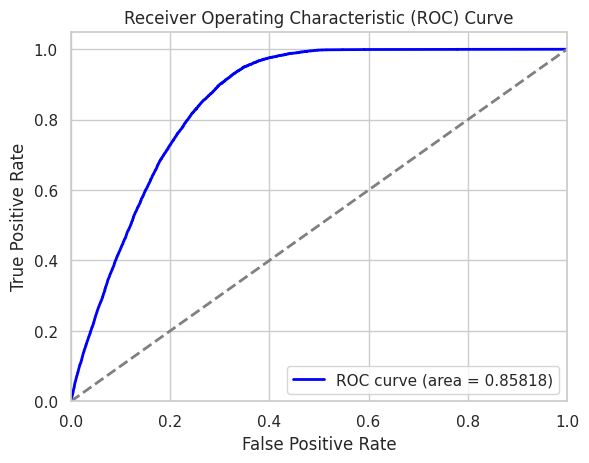

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(test_y, val_pred_prob)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {auc:.5f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Blue Curve:

* Plots the trade-off between TPR and FPR at different classification thresholds.

Diagonal Line (gray):

* Represents a random classifier (AUC = 0.5). Any model performing better than random lies above this line.

Area Under the Curve (AUC):

<b>In our plot: AUC = 0.86984</b>

* This means the model has a very good ability to distinguish between the two classes.

            AUC = 1.0: Perfect classifier

            AUC > 0.8: Strong performance

            AUC ≈ 0.5: No discriminative power (random guessing)



<h2>SUMMARY</h2>

After testing 4 different Classification models we got some accuracy scores which clearly depicts which is the best performing model:

            Classifier Model                ACCURACY                            

            1) Decision Tree                84%                                 

            2) Logistic Regression          83%                                 

            3) Random Forest                88%                                 

            4) XGBoosting Classifier        86.984%                             

<h4><b>The Random Forest Classifer gives the best accuracy for the Health insurance cross sell prediction Dataset</b></h4>

In [44]:
import joblib

# Save models
joblib.dump(log_reg_model, "logistic_regression.pkl")
joblib.dump(rf_model, "random_forest.pkl")
joblib.dump(xgb_model, "xgboost.pkl")
joblib.dump(dt_model, "decision_tree.pkl")

print("All models saved successfully")

All models saved successfully


In [45]:
from google.colab import files

files.download("logistic_regression.pkl")
files.download("random_forest.pkl")
files.download("xgboost.pkl")
files.download("decision_tree.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: scaler.pkl

In [46]:
from google.colab import files
files.download('/content/specialiasation_class.ipynb')

FileNotFoundError: Cannot find file: /content/specialiasation_class.ipynb